# 07 · Transfer Learning

**A note on scope.** "Real" transfer learning usually starts from a large model
pretrained on millions of images (ImageNet) and fine-tunes it on a new task. Doing
that reliably here would mean downloading tens or hundreds of megabytes of pretrained
weights, which is exactly the kind of external dependency this course avoids. Instead,
this chapter **trains its own small feature extractor from scratch** on one task and
then reuses it on a second, related task with almost no labels — the same mechanism
transfer learning relies on, at a scale that trains in seconds and needs nothing but
what's already installed.

**Objectives:** train a small CNN on one classification task, freeze its convolutional
layers, and show that the features it learned generalise to a second task where a
plain classifier trained from scratch, with the same tiny number of labels, does not.

## 1. Convolution: one small filter slid across the image

A digit image here is an $8\times 8$ grid of pixel intensities between 0 and 1. A
dense layer treats those 64 numbers as an unordered list. It does not know that
pixel $(3, 4)$ sits next to pixel $(3, 5)$, and a pattern it learns in one corner has
to be learned again for every other position. A **convolutional layer** builds in two
facts about images: nearby pixels belong together, and the same pattern (an edge, the
end of a stroke, a curve) can appear anywhere.

**Definition.** Let $x$ be an image with entries $x[i,j]$ (row $i$, column $j$), and
let $w$ be a small **kernel** (or filter), here $3\times 3$, with entries $w[m,n]$ for
$m, n \in \{0, 1, 2\}$. The discrete 2-D convolution produces a new grid

$$(x * w)[i,j] = \sum_{m=0}^{2}\sum_{n=0}^{2} w[m,n]\;x[i+m,\,j+n] .$$

Read it as: lay the kernel over the $3\times 3$ patch whose top-left corner is at
$(i, j)$, multiply the overlapping numbers pair by pair, and add the nine products.
Then slide one pixel and repeat. The result is large where the patch looks like the
kernel and small or negative where it does not, so each kernel is a **pattern
detector**. (Textbook convolution flips the kernel first; without the flip the
operation is called cross-correlation. Deep-learning libraries compute the unflipped
version and call it convolution. Since the kernel is learned, the flip makes no
difference.)

On an $H\times W$ image a $3\times 3$ kernel fits in $(H-2)\times(W-2)$ positions. With
`padding="same"`, a border of zeros is added first so that the output keeps the input
size, $8\times 8$ here.

A convolutional layer adds a bias $b$ and an activation, giving a **feature map**
$a[i,j] = \mathrm{ReLU}\big((x*w)[i,j] + b\big)$, and it uses many kernels at once, one
feature map per kernel. `conv1` has 16 kernels, so it turns the $8\times8\times1$ image
into $8\times8\times16$ feature maps. When the input already has $C$ channels, like the
16 maps entering `conv2`, each kernel is $3\times3\times C$ and the sum also runs over
the channels.

**Weight sharing.** The same kernel weights are used at every position, so the number
of parameters does not depend on the image size. For kernel size $K$, $C_{\text{in}}$
input channels and $C_{\text{out}}$ kernels, each with one bias:

$$\text{parameters} = (K\cdot K\cdot C_{\text{in}} + 1)\cdot C_{\text{out}} .$$

For `conv1` this is $(3\cdot3\cdot1+1)\cdot16 = 160$. A dense layer producing the same
$8\cdot8\cdot16 = 1024$ outputs from the 64 input pixels needs one weight per
input-output pair plus one bias per output: $64\cdot1024 + 1024 = 66{,}560$ parameters,
about 416 times more. Sharing weights also fixes how the layer reacts to shifts: move
the input by one pixel and the feature map moves by one pixel with it. This property
is called **translation equivariance**.

**Worked example.** A $5\times 5$ image with a vertical stroke in column 2 (columns
numbered 0 to 4), and a kernel that responds to vertical strokes:

$$x = \begin{bmatrix}0&0&1&0&0\\0&0&1&0&0\\0&0&1&0&0\\0&0&1&0&0\\0&0&1&0&0\end{bmatrix},
\qquad
w = \begin{bmatrix}-1&2&-1\\-1&2&-1\\-1&2&-1\end{bmatrix}.$$

Without padding the output is $3\times 3$. Each kernel row meets an identical image
row, so each output is 3 times the product for one row:

| output | patch columns | one kernel row times one image row | sum of 3 rows |
|---|---|---|---|
| $(x*w)[0,0]$ | 0, 1, 2 | $(-1)\cdot 0 + 2\cdot 0 + (-1)\cdot 1 = -1$ | $-3$ |
| $(x*w)[0,1]$ | 1, 2, 3 | $(-1)\cdot 0 + 2\cdot 1 + (-1)\cdot 0 = 2$ | $6$ |
| $(x*w)[0,2]$ | 2, 3, 4 | $(-1)\cdot 1 + 2\cdot 0 + (-1)\cdot 0 = -1$ | $-3$ |

All image rows are the same, so every output row is $(-3, 6, -3)$, and after ReLU it
is $(0, 6, 0)$: the map lights up exactly over the stroke. Now shift the stroke one
column to the right, to column 3. The output rows become $(0, -3, 6)$, and after ReLU
$(0, 0, 6)$. The detection moved with the stroke, and its strength, 6, did not
change.

## 2. Pooling, depth, and learned features

**Pooling** summarises a feature map. **Max pooling** with a $2\times 2$ window
(`pool1`) keeps the largest value in each non-overlapping $2\times 2$ block:

$$p[i,j] = \max\big\{a[2i,2j],\; a[2i,2j+1],\; a[2i+1,2j],\; a[2i+1,2j+1]\big\} .$$

The $8\times 8$ maps become $4\times 4$, and a feature that moves by one pixel within a
block gives the same pooled value. **Global average pooling** (`gap`) goes all the
way: it replaces each whole $H\times W$ feature map by its average,
$\frac{1}{HW}\sum_{i,j} a[i,j]$, leaving one number per channel. In the worked example
the largest value in the map is 6 before and after the shift: after pooling, the
answer to "is there a vertical stroke?" no longer depends on where the stroke is.
This built-in tolerance of small shifts matters below, because the target digits are
shifted and rotated.

**Depth makes features more abstract.** A unit of `conv1` sees a $3\times 3$ patch of
the image: its **receptive field** is 3 pixels wide. After `pool1`, each unit covers
$4\times 4$ pixels, and neighbouring pooled units are 2 pixels apart. A $3\times 3$
kernel in `conv2` spans three pooled units, so its receptive field is
$4 + 2\cdot 2 = 8$ pixels: the whole digit. The first layer can only detect local
things such as edges and stroke directions. The second combines them into larger
parts such as loops, corners and junctions. The dense layer `feat` combines those
into 32 numbers that describe the digit as a whole. In large networks trained on
photographs the same progression is observed directly: edges, then textures, then
object parts, then objects.

**The whole source model, counted.**

| layer | output shape | parameters |
|---|---|---|
| `conv1`: 16 kernels of $3\times3\times1$ | $8\times8\times16$ | $(9+1)\cdot16 = 160$ |
| `pool1` | $4\times4\times16$ | 0 |
| `conv2`: 32 kernels of $3\times3\times16$ | $4\times4\times32$ | $(144+1)\cdot32 = 4{,}640$ |
| `gap` | $32$ | 0 |
| `feat`: dense | $32$ | $32\cdot32+32 = 1{,}056$ |
| `source_head`: dense, softmax | $10$ | $32\cdot10+10 = 330$ |

The head produces 10 scores $s_1, \dots, s_{10}$ and turns them into class
probabilities with the **softmax**, $p_c = e^{s_c}/\sum_{c'} e^{s_{c'}}$, which are
positive and add up to 1.

## 3. Transfer: keep the features, retrain the head

**A model in two parts.** Write the network as a **feature extractor** followed by a
**head**:

$$\text{model}(x) = g_\phi\big(f_\theta(x)\big) .$$

$f_\theta$ maps an image to a feature vector in $\mathbb{R}^{32}$. Its parameters
$\theta$ are the weights of `conv1`, `conv2` and `feat`, $160 + 4640 + 1056 = 5{,}856$
numbers. $g_\phi$ maps the features to 10 class probabilities; its parameters $\phi$
are the 330 weights of `source_head`.

**Two tasks, two distributions.** In the **source** task the images come from a
distribution $P_S(x)$: clean, centred digits, with many labels. In the **target** task
they come from $P_T(x)$: the same digits, rotated and shifted, with few labels. So
$P_S(x) \neq P_T(x)$; this mismatch is called **domain shift**. What stays the same is
the meaning of the labels: a rotated 3 is still a 3, so the rule linking an image to
its class, $P(y \mid x)$, is shared. Transfer learning bets that features useful for
the source task are also useful for the target task.

**Freezing.** Source training fits both parts together, on $N_S$ labelled source
images with the cross-entropy loss $\ell$:

$$\theta^\ast,\ \phi^\ast = \arg\min_{\theta,\,\phi}\ \frac{1}{N_S}\sum_{i=1}^{N_S} \ell\big(g_\phi(f_\theta(x_i)),\ y_i\big) .$$

For the target task, keep $\theta^\ast$ fixed (**frozen**) and fit only a new head
$h_\psi$ with parameters $\psi$, on the $N_T$ labelled target images:

$$\psi^\ast = \arg\min_{\psi}\ \frac{1}{N_T}\sum_{i=1}^{N_T} \ell\big(h_\psi(f_{\theta^\ast}(x_i)),\ y_i\big) .$$

Each target image is turned once into its 32 features, and the new head is an
ordinary classifier trained on those features.

**Why this helps when labels are scarce.** Compare parameters with labelled examples.
With 3 labels per class there are $N_T = 30$ target examples. A logistic regression on
the 64 raw pixels has $10\cdot(64+1) = 650$ parameters, and training the whole network
from scratch would mean more than 6,000. On the 32 frozen features the head has
$10\cdot(32+1) = 330$ parameters. More importantly, the hard part, learning what
strokes and shapes look like, was already done with about 1,440 labelled source
images. The few target labels only need to say which region of feature space belongs
to which digit. The price is flexibility: frozen features cannot adapt to anything
the source task never taught them.

**Feature extraction vs. fine-tuning.** The approach above is **feature extraction**:
$\theta$ never changes. **Fine-tuning** starts from $\theta^\ast$ and continues to train
all parameters on the target data, usually with a small learning rate so that the
weights stay near where they started. Fine-tuning can adapt the features to the new
domain, but with very few labels it can overfit and erase what was learned. A common
rule: freeze when target labels are scarce, fine-tune when there are more of them.

**In the code.** `source_model` is $g_\phi \circ f_\theta$, trained on the clean digits
`Xc_train`. `feature_extractor = tf.keras.Model(inp, features)` is $f_{\theta^\ast}$ on
its own; it stays frozen because it is only ever used for prediction afterwards. In
section 6, `fewshot_accuracy` trains a `LogisticRegression` head $h_\psi$ on
`feature_extractor.predict(...)` outputs for the transfer model, and the same
classifier directly on the 64 raw pixels for the from-scratch baseline, with 3, 5 or
8 labels per class.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from scipy.ndimage import rotate, shift
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import mlutils
mlutils.set_style()
tf.get_logger().setLevel("ERROR")
tf.keras.utils.set_random_seed(1)          # seeds Python, NumPy and TensorFlow together
tf.config.experimental.enable_op_determinism()  # identical results on every run
rng = np.random.default_rng(0)

## 4. Source task: clean handwritten digits

`sklearn`'s digits dataset: 1797 handwritten digits, 8x8 pixels, already on disk —
no download needed. We train a small CNN to recognise all 10 digits from clean,
centred images. This is the **source task**: plenty of labels, and it's what the
feature extractor will actually learn from.

Text(0.5, 0.98, 'Source task: clean, centred digits')

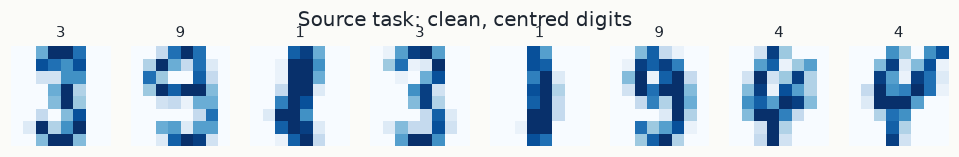

In [2]:
digits = load_digits()
X_clean = (digits.images / 16.0)[..., np.newaxis].astype("float32")
y_clean = digits.target

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=0, stratify=y_clean)

fig, axes = plt.subplots(1, 8, figsize=(11, 1.6))
for ax, img, label in zip(axes, Xc_train[:8], yc_train[:8]):
    ax.imshow(img.squeeze(), cmap="Blues")
    ax.set_title(str(label), fontsize=10)
    ax.axis("off")
fig.suptitle("Source task: clean, centred digits")

In [3]:
inp = tf.keras.Input(shape=(8, 8, 1))
z = tf.keras.layers.Conv2D(16, 3, activation="relu", padding="same", name="conv1")(inp)
z = tf.keras.layers.MaxPooling2D(2, name="pool1")(z)
z = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same", name="conv2")(z)
z = tf.keras.layers.GlobalAveragePooling2D(name="gap")(z)
features = tf.keras.layers.Dense(32, activation="relu", name="feat")(z)
out = tf.keras.layers.Dense(10, activation="softmax", name="source_head")(features)

source_model = tf.keras.Model(inp, out)
source_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
source_model.fit(Xc_train, yc_train, epochs=20, batch_size=32, verbose=0)
acc_source = source_model.evaluate(Xc_test, yc_test, verbose=0)[1]
print(f"source task test accuracy: {acc_source:.3f}")

feature_extractor = tf.keras.Model(inp, features)   # everything up to (not including) the source head

source task test accuracy: 0.917


## 5. Target task: the same digits, shifted and rotated, almost unlabelled

The **target task** is deliberately related but different: the same 10 digit classes,
but every image is randomly rotated (up to 20°) and shifted by a couple of pixels —
and we only keep a handful of labelled examples per class, simulating the situation
transfer learning is actually for: a new domain where labels are scarce.

Text(0.5, 0.98, 'Target task: same digits, rotated + shifted')

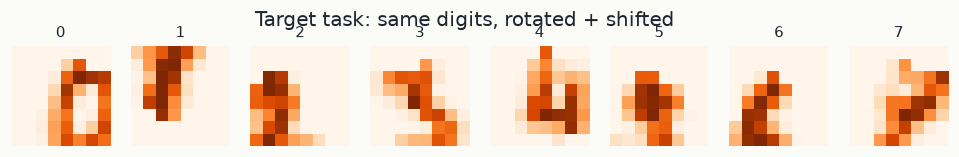

In [4]:
def perturb(img):
    dx, dy = rng.integers(-2, 3, size=2)
    angle = rng.uniform(-20, 20)
    warped = rotate(img, angle, reshape=False, order=1, mode="constant")
    warped = shift(warped, (dy, dx), order=1, mode="constant")
    return np.clip(warped, 0, 1)

X_shifted = np.stack([perturb(im) for im in (digits.images / 16.0)])[..., np.newaxis].astype("float32")
y_shifted = digits.target.copy()

fig, axes = plt.subplots(1, 8, figsize=(11, 1.6))
for ax, img, label in zip(axes, X_shifted[:8], y_shifted[:8]):
    ax.imshow(img.squeeze(), cmap="Oranges")
    ax.set_title(str(label), fontsize=10)
    ax.axis("off")
fig.suptitle("Target task: same digits, rotated + shifted")

## 6. Few-shot comparison: raw pixels vs. transferred features

With only a handful of labelled target examples per class, we compare two simple
classifiers built on top of them:

- **From scratch:** logistic regression directly on the raw (shifted, rotated) pixels.
- **Transfer learning:** run each image through the *frozen* feature extractor from
  the source task, then logistic regression on those 32-dimensional features.

Neither approach touches the convolutional weights again — the only thing trained on
the target task's tiny label set is a linear classifier, which keeps the comparison
about the features themselves, not about how much fine-tuning either gets.

In [5]:
def fewshot_accuracy(per_class, n_trials=6, seed=0):
    trial_rng = np.random.default_rng(seed)
    raw_accs, transfer_accs = [], []
    for _ in range(n_trials):
        train_idx = []
        for c in range(10):
            class_idx = np.where(y_shifted == c)[0]
            train_idx.extend(trial_rng.choice(class_idx, size=per_class, replace=False))
        train_idx = np.array(train_idx)
        test_idx = np.array([i for i in range(len(y_shifted)) if i not in set(train_idx)])

        y_tr, y_te = y_shifted[train_idx], y_shifted[test_idx]

        X_tr_raw = X_shifted[train_idx].reshape(len(train_idx), -1)
        X_te_raw = X_shifted[test_idx].reshape(len(test_idx), -1)
        clf_raw = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_tr_raw, y_tr)
        raw_accs.append(clf_raw.score(X_te_raw, y_te))

        X_tr_feat = feature_extractor.predict(X_shifted[train_idx], verbose=0)
        X_te_feat = feature_extractor.predict(X_shifted[test_idx], verbose=0)
        clf_feat = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)).fit(X_tr_feat, y_tr)
        transfer_accs.append(clf_feat.score(X_te_feat, y_te))
    return np.mean(raw_accs), np.mean(transfer_accs)

per_class_options = [3, 5, 8]
results = [fewshot_accuracy(pc) for pc in per_class_options]
for pc, (raw_acc, transfer_acc) in zip(per_class_options, results):
    print(f"{pc} labelled examples/class -> from scratch: {raw_acc:.3f}   transfer learning: {transfer_acc:.3f}")

3 labelled examples/class -> from scratch: 0.161   transfer learning: 0.254
5 labelled examples/class -> from scratch: 0.178   transfer learning: 0.320
8 labelled examples/class -> from scratch: 0.167   transfer learning: 0.371


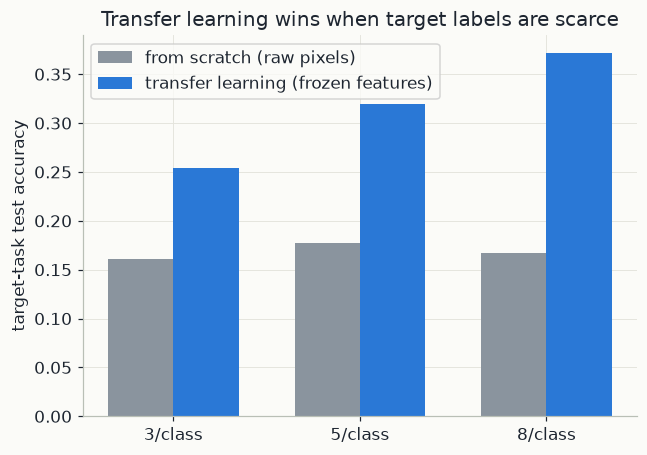

In [6]:
raw_accs = [r[0] for r in results]
transfer_accs = [r[1] for r in results]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
width = 0.35
xs = np.arange(len(per_class_options))
ax.bar(xs - width/2, raw_accs, width, color=mlutils.GREY, label="from scratch (raw pixels)")
ax.bar(xs + width/2, transfer_accs, width, color=mlutils.BLUE, label="transfer learning (frozen features)")
ax.set(xticks=xs, xticklabels=[f"{pc}/class" for pc in per_class_options],
       ylabel="target-task test accuracy", title="Transfer learning wins when target labels are scarce")
ax.legend()

With only a few labelled examples per class, reusing features learned on the (larger,
clean) source task clearly beats learning from the shifted target pixels directly.
The convolution-and-pooling architecture picked up features that tolerate small
shifts and rotations because it saw *many* clean digits during source training; raw
pixel classifiers have no such tolerance and a handful of labels isn't enough to learn
it from scratch.

## Exercises

### Exercise 1: More labels closes the gap
Extend `per_class_options` to include 15 and 25. Does the transfer-learning advantage
shrink as more target labels become available?

<details><summary>Solution</summary>

```python
print(fewshot_accuracy(15))
print(fewshot_accuracy(25))
```
Yes — with enough target-task labels, a classifier trained from scratch can learn
shift/rotation tolerance on its own, and the gap narrows. Transfer learning helps most
exactly when labels are scarce, which is the point of the technique.
</details>

### Exercise 2: Fine-tune instead of freezing
Instead of a frozen feature extractor + linear classifier, unfreeze `conv1`/`conv2`
and fine-tune the whole network (with a small learning rate) on the few-shot target
set. Does it beat the frozen-feature approach, or does it overfit with so few
examples?

<details><summary>Solution</summary>

With only a handful of examples per class, fine-tuning every convolutional weight
usually overfits badly — there simply isn't enough signal to safely move that many
parameters. Freezing the features and only fitting a linear classifier, as in this
chapter, is the safer choice in the extreme few-shot regime; fine-tuning becomes
worthwhile once there are more target labels.
</details>

## Key takeaways

- Transfer learning reuses features learned on a data-rich **source task** for a
  related, label-scarce **target task**, instead of training a new model from zero on
  too little data.
- Freezing the pretrained layers and fitting only a small classifier head is a strong,
  low-risk baseline exactly when target labels are scarce.
- The benefit is largest precisely when target labels are scarce; with enough target
  data, training from scratch catches up.